<a href="https://www.kaggle.com/code/aamir28/genai-adoption-analysis-2022-2025?scriptVersionId=319719298" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🌐 GAAII — Exploratory Data Analysis & Starter Notebook
### Global GenAI Adoption & Impact Index 2022–2025

This notebook is your launchpad into the GAAII dataset. It covers:
1. Dataset loading & structure
2. Global adoption trends over time
3. Income group disparities
4. Policy vs. adoption tradeoffs
5. Job impact analysis
6. Public trust & anxiety dynamics
7. Equity & access gaps
8. Research output leaders
9. Incident heatmap by category
10. Starter ML: predicting regulation adoption


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── Load datasets ──────────────────────────────────────────────────────────
df   = pd.read_csv('/kaggle/input/datasets/aamir28/global-genai-adoption-and-impact-index-2022-2025/gaaii_country_year.csv')
pol  = pd.read_csv('/kaggle/input/datasets/aamir28/global-genai-adoption-and-impact-index-2022-2025/gaaii_policy_events.csv')
inc  = pd.read_csv('/kaggle/input/datasets/aamir28/global-genai-adoption-and-impact-index-2022-2025/gaaii_incidents.csv')
srv  = pd.read_csv('/kaggle/input/datasets/aamir28/global-genai-adoption-and-impact-index-2022-2025/gaaii_survey_microdata.csv')
mdl  = pd.read_csv('/kaggle/input/datasets/aamir28/global-genai-adoption-and-impact-index-2022-2025/gaaii_model_releases.csv')

print(f'Main dataset : {df.shape}')
print(f'Policy events: {pol.shape}')
print(f'Incidents    : {inc.shape}')
print(f'Survey micro : {srv.shape}')
print(f'Model releases: {mdl.shape}')

Main dataset : (552, 63)
Policy events: (520, 12)
Incidents    : (1800, 16)
Survey micro : (22989, 22)
Model releases: (70, 11)


## 1. Global GenAI Adoption Trend (2022–2025)
How fast did the world adopt GenAI tools?

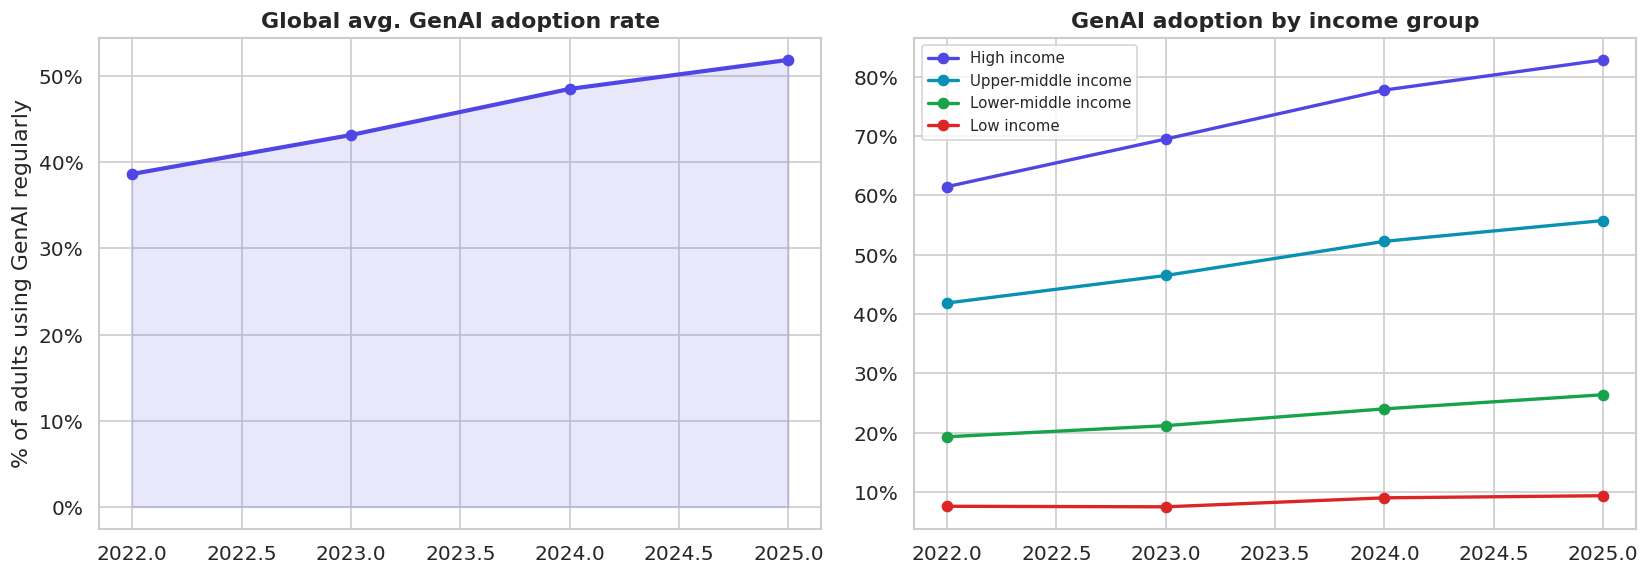

In [2]:
trend = df.groupby(['year','income_group'])['genai_adoption_rate_pct'].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
overall = df.groupby('year')['genai_adoption_rate_pct'].mean()
axes[0].plot(overall.index, overall.values, marker='o', linewidth=2.5, color='#4f46e5')
axes[0].fill_between(overall.index, overall.values, alpha=0.12, color='#4f46e5')
axes[0].set_title('Global avg. GenAI adoption rate', fontweight='bold')
axes[0].set_ylabel('% of adults using GenAI regularly')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))

# By income group
order = ['High income','Upper-middle income','Lower-middle income','Low income']
colors = ['#4f46e5','#0891b2','#16a34a','#dc2626']
for ig, col in zip(order, colors):
    sub = trend[trend.income_group==ig]
    axes[1].plot(sub.year, sub.genai_adoption_rate_pct, marker='o', label=ig, color=col, linewidth=2)
axes[1].set_title('GenAI adoption by income group', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('adoption_trend.png', bbox_inches='tight')
plt.show()

## 2. Top 20 Countries by GAAII Score (2025)
Which countries lead the global GenAI readiness ranking?

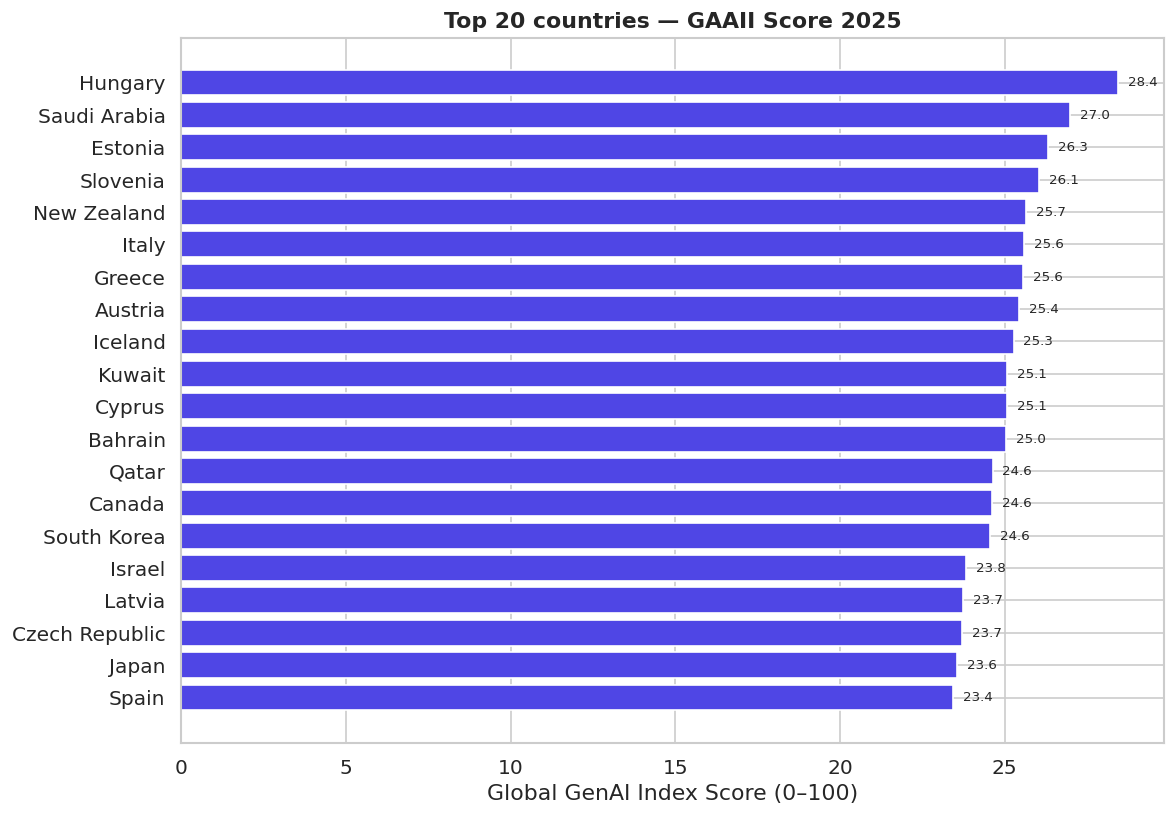

In [3]:
top20 = df[df.year==2025].nlargest(20,'global_genai_index_score')[['country','global_genai_index_score','income_group']]

palette = {'High income':'#4f46e5','Upper-middle income':'#0891b2',
           'Lower-middle income':'#16a34a','Low income':'#dc2626'}
colors = [palette[ig] for ig in top20.income_group]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20.country, top20.global_genai_index_score, color=colors, edgecolor='white')
ax.set_xlabel('Global GenAI Index Score (0–100)')
ax.set_title('Top 20 countries — GAAII Score 2025', fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, top20.global_genai_index_score):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 3. The Regulation–Adoption Tradeoff
Do stricter regulatory regimes slow or accelerate GenAI adoption?

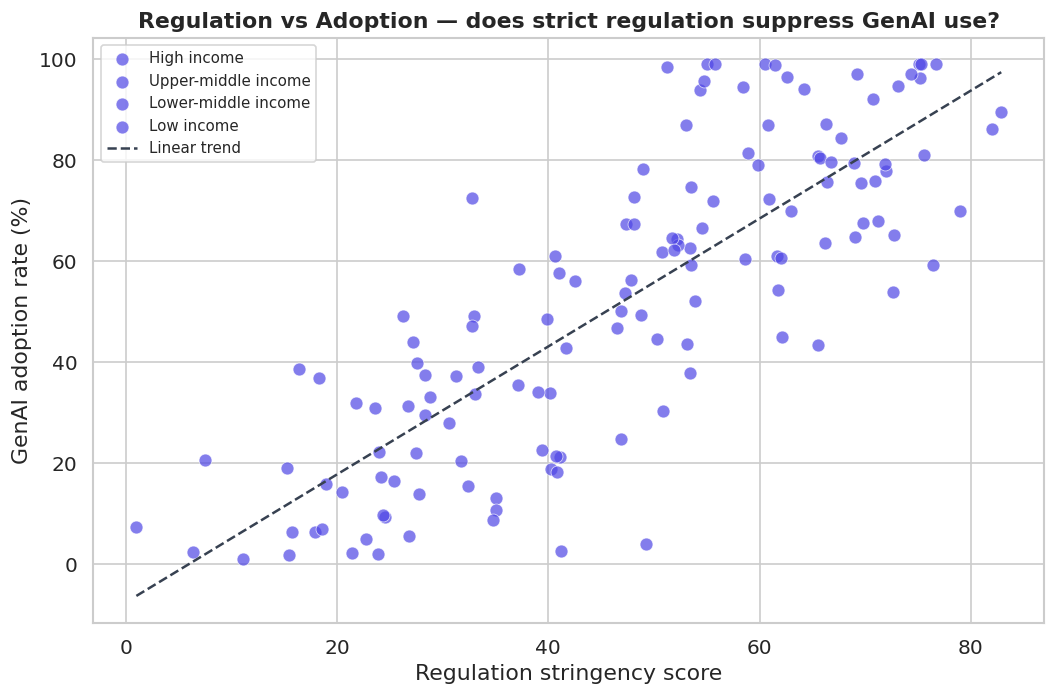

Pearson correlation (regulation vs adoption): 0.814


In [4]:
d25 = df[df.year==2025]
fig, ax = plt.subplots(figsize=(9, 6))
for ig, col in zip(order, colors):
    sub = d25[d25.income_group==ig]
    ax.scatter(sub.regulation_stringency_score, sub.genai_adoption_rate_pct,
               label=ig, color=col, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

# Trend line
m, b = np.polyfit(d25.regulation_stringency_score, d25.genai_adoption_rate_pct, 1)
x_line = np.linspace(d25.regulation_stringency_score.min(), d25.regulation_stringency_score.max(), 100)
ax.plot(x_line, m*x_line+b, '--', color='#374151', linewidth=1.5, label='Linear trend')

ax.set_xlabel('Regulation stringency score')
ax.set_ylabel('GenAI adoption rate (%)')
ax.set_title('Regulation vs Adoption — does strict regulation suppress GenAI use?', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

corr = d25[['regulation_stringency_score','genai_adoption_rate_pct']].corr().iloc[0,1]
print(f'Pearson correlation (regulation vs adoption): {corr:.3f}')

## 4. Net Job Impact — Who Wins and Who Loses?
Mapping the job creation vs displacement dynamic across income groups.

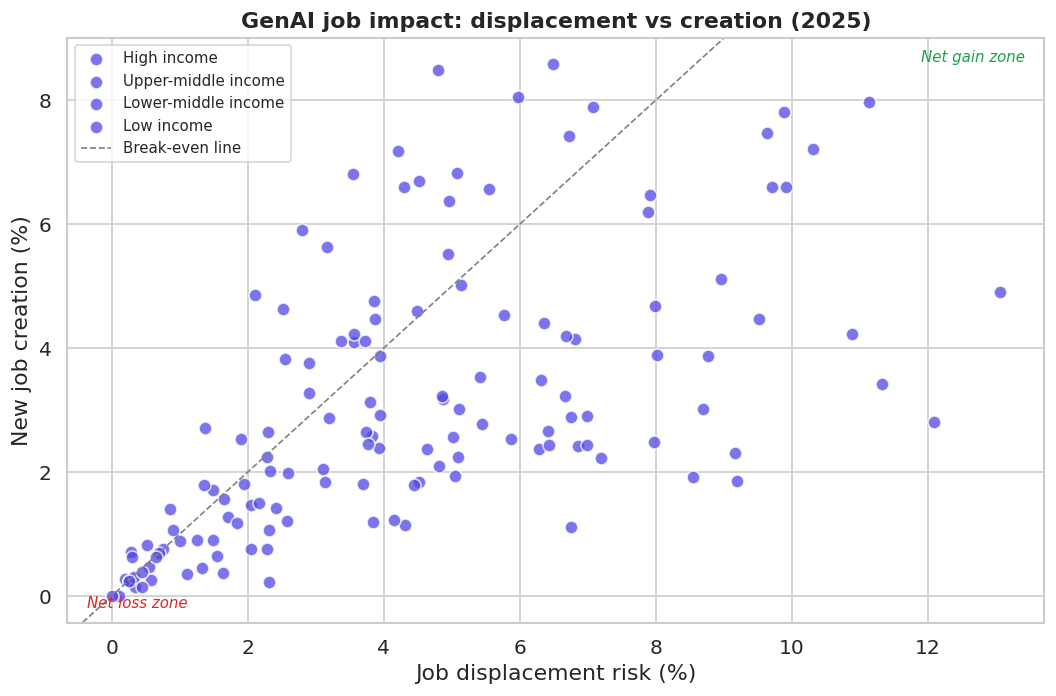

In [5]:
d25 = df[df.year==2025].copy()
fig, ax = plt.subplots(figsize=(9,6))
for ig, col in zip(order, colors):
    sub = d25[d25.income_group==ig]
    ax.scatter(sub.job_displacement_pct, sub.job_creation_pct,
               label=ig, color=col, alpha=0.75, s=60, edgecolors='white')
ax.axline((0,0), slope=1, linestyle='--', color='gray', linewidth=1, label='Break-even line')
ax.set_xlabel('Job displacement risk (%)')
ax.set_ylabel('New job creation (%)')
ax.set_title('GenAI job impact: displacement vs creation (2025)', fontweight='bold')
ax.legend(fontsize=9)
# Annotate quadrants
ax.text(0.98, 0.98, 'Net gain zone', transform=ax.transAxes, ha='right', va='top',
        color='#16a34a', fontsize=9, fontstyle='italic')
ax.text(0.02, 0.02, 'Net loss zone', transform=ax.transAxes, ha='left', va='bottom',
        color='#dc2626', fontsize=9, fontstyle='italic')
plt.tight_layout()
plt.show()

## 5. Trust vs Anxiety — The Public Perception Map

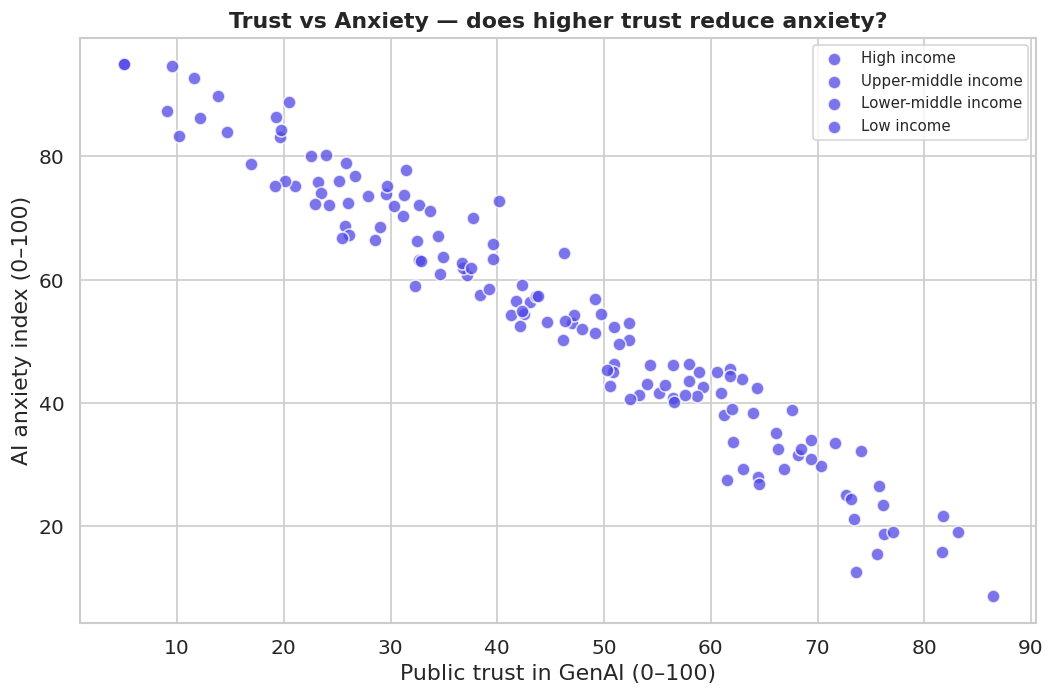

In [6]:
fig, ax = plt.subplots(figsize=(9,6))
for ig, col in zip(order, colors):
    sub = d25[d25.income_group==ig]
    ax.scatter(sub.public_trust_score, sub.ai_anxiety_index,
               label=ig, color=col, alpha=0.75, s=60, edgecolors='white')
ax.set_xlabel('Public trust in GenAI (0–100)')
ax.set_ylabel('AI anxiety index (0–100)')
ax.set_title('Trust vs Anxiety — does higher trust reduce anxiety?', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. Equity Gap — Digital Divide vs GenAI Adoption

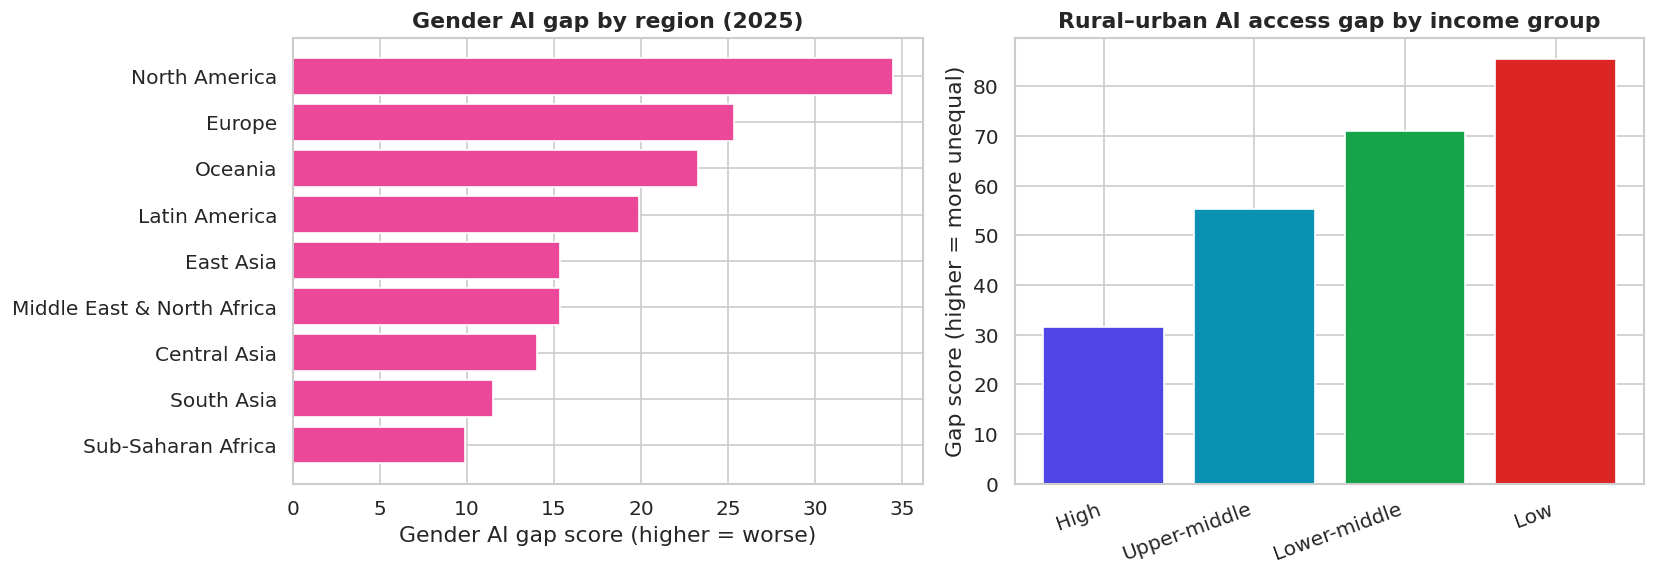

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Gender gap by region
gender_gap = df[df.year==2025].groupby('region')['gender_ai_gap_score'].mean().sort_values()
axes[0].barh(gender_gap.index, gender_gap.values, color='#ec4899')
axes[0].set_title('Gender AI gap by region (2025)', fontweight='bold')
axes[0].set_xlabel('Gender AI gap score (higher = worse)')

# Rural-urban gap
rur = df[df.year==2025].groupby('income_group')['rural_urban_ai_gap_score'].mean().reindex(order)
axes[1].bar(range(len(order)), rur.values, color=['#4f46e5','#0891b2','#16a34a','#dc2626'])
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels([x.replace(' income','') for x in order], rotation=20, ha='right')
axes[1].set_title('Rural–urban AI access gap by income group', fontweight='bold')
axes[1].set_ylabel('Gap score (higher = more unequal)')

plt.tight_layout()
plt.show()

## 7. GenAI Incidents — Category Breakdown

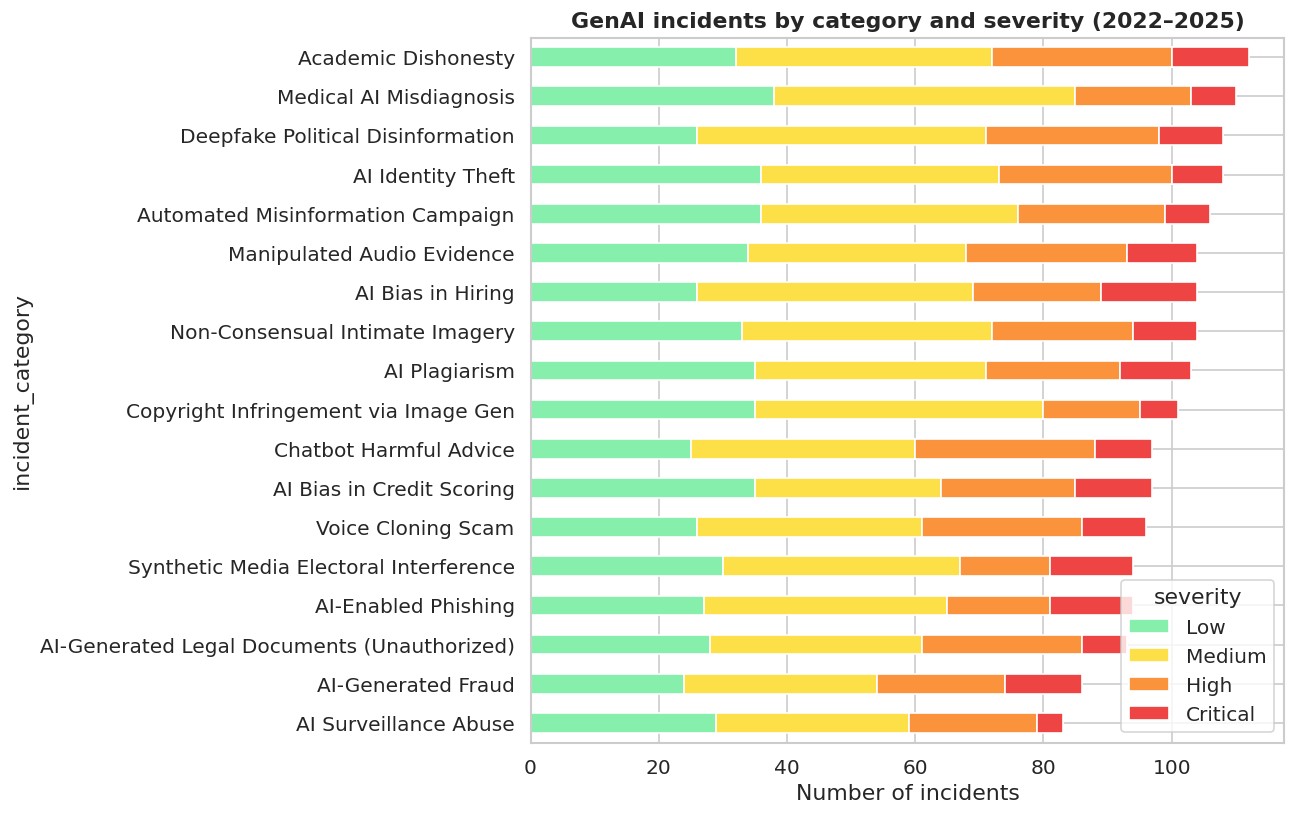

In [8]:
inc_count = inc.groupby(['incident_category','severity']).size().unstack(fill_value=0)
sev_order = ['Low','Medium','High','Critical']
inc_count = inc_count.reindex(columns=[s for s in sev_order if s in inc_count.columns])
inc_count['total'] = inc_count.sum(axis=1)
inc_count = inc_count.sort_values('total', ascending=True).drop(columns='total')

inc_count.plot(kind='barh', stacked=True, figsize=(11,7),
               color=['#86efac','#fde047','#fb923c','#ef4444'])
plt.title('GenAI incidents by category and severity (2022–2025)', fontweight='bold')
plt.xlabel('Number of incidents')
plt.tight_layout()
plt.show()

## 8. Survey Microdata — Trust by Age Group & Country Income

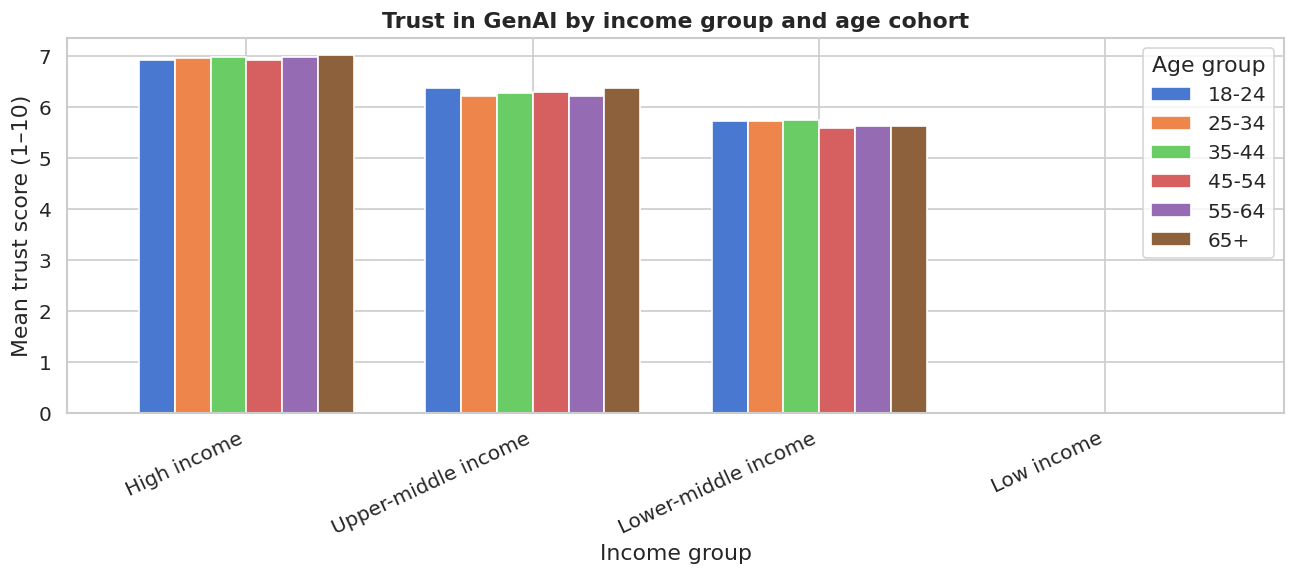

In [9]:
age_order = ['18-24','25-34','35-44','45-54','55-64','65+']
trust_age = srv.groupby(['income_group','age_group'])['trust_in_genai_score'].mean().unstack()
trust_age = trust_age.reindex(columns=[a for a in age_order if a in trust_age.columns])
trust_age.reindex(order).plot(kind='bar', figsize=(11,5), width=0.75)
plt.title('Trust in GenAI by income group and age cohort', fontweight='bold')
plt.xlabel('Income group')
plt.ylabel('Mean trust score (1–10)')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Age group', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

## 9. Model Release Timeline — Parameters vs Benchmark Score

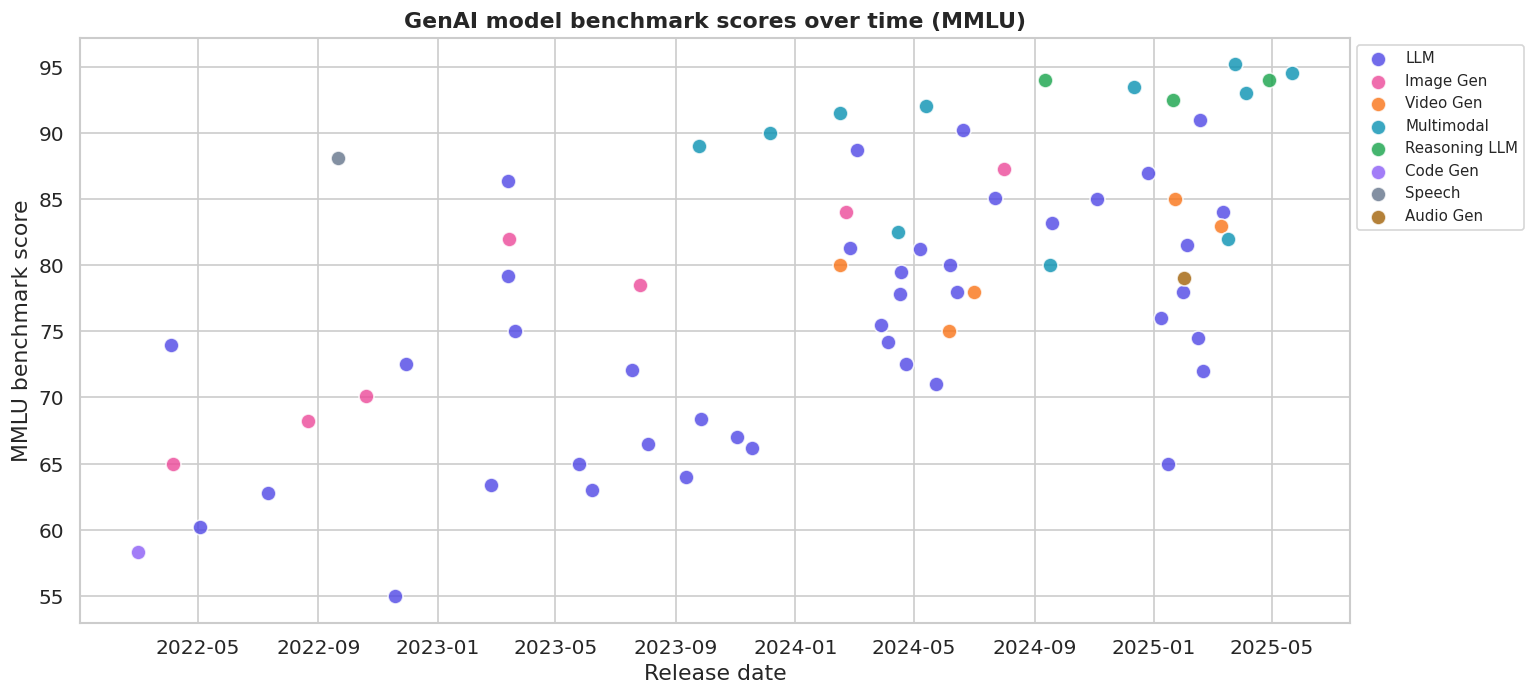

In [10]:
mdl2 = mdl.dropna(subset=['benchmark_score_mmlu'])
mdl2['release_date'] = pd.to_datetime(mdl2['release_date'])
cat_colors = {'LLM':'#4f46e5','Image Gen':'#ec4899','Video Gen':'#f97316',
              'Multimodal':'#0891b2','Reasoning LLM':'#16a34a','Code Gen':'#8b5cf6',
              'Speech':'#64748b','Audio Gen':'#a16207'}

fig, ax = plt.subplots(figsize=(13,6))
for cat, col in cat_colors.items():
    sub = mdl2[mdl2.category==cat]
    ax.scatter(sub.release_date, sub.benchmark_score_mmlu, label=cat,
               color=col, s=80, alpha=0.8, edgecolors='white')

ax.set_title('GenAI model benchmark scores over time (MMLU)', fontweight='bold')
ax.set_ylabel('MMLU benchmark score')
ax.set_xlabel('Release date')
ax.legend(fontsize=9, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

## 10. Starter ML — Predicting Deepfake Law Enactment
Can we predict which countries will pass deepfake legislation based on national characteristics?

Classification Report:
              precision    recall  f1-score   support

      No law       0.72      0.93      0.81        76
  Law exists       0.58      0.20      0.30        35

    accuracy                           0.70       111
   macro avg       0.65      0.57      0.55       111
weighted avg       0.67      0.70      0.65       111



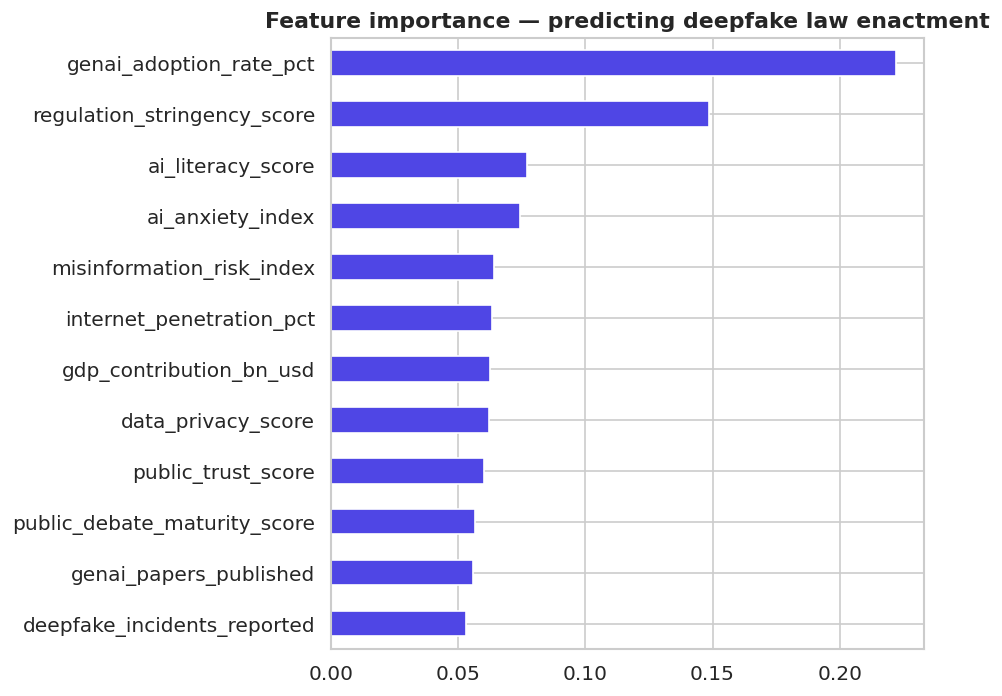

In [11]:
features = [
    'genai_adoption_rate_pct','regulation_stringency_score','data_privacy_score',
    'public_trust_score','ai_anxiety_index','misinformation_risk_index',
    'internet_penetration_pct','ai_literacy_score','genai_papers_published',
    'deepfake_incidents_reported','gdp_contribution_bn_usd','public_debate_maturity_score'
]

ml_df = df[features + ['deepfake_law_exists']].dropna()
X = ml_df[features]
y = ml_df['deepfake_law_exists']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No law','Law exists']))

# Feature importance
fi = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8,6))
fi.plot(kind='barh', ax=ax, color='#4f46e5', edgecolor='white')
ax.set_title('Feature importance — predicting deepfake law enactment', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Next Steps

Explore these directions with the full dataset:

- **Time series forecasting**: predict 2026 adoption rates per country using ARIMA, Prophet, or LSTM
- **Clustering**: identify country archetypes (e.g., 'Regulated early adopters', 'Unregulated laggards') using K-Means or HDBSCAN
- **NLP on policy events**: sentiment/stance detection on policy event text
- **Causal inference**: did passing a national AI strategy *cause* faster adoption? Use diff-in-diff
- **Fairness analysis**: measure AI literacy gap by gender and urbanicity from survey microdata
- **Graph analysis**: build country collaboration networks from `intl_ai_collaboration_score`

Happy exploring! 🚀
